## 1 Carregamento e Divisão

In [1]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Carregar
df = pd.read_csv('../data/processed/healthcare_fraud_final_model.csv')

# Separar X e y
X = df.drop('Is_Fraud', axis=1)
y = df['Is_Fraud']

# Divisão (80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## 2 Normalização (Standard Scaler) Manual

In [2]:
from sklearn.preprocessing import StandardScaler

# Lista das colunas numéricas (lembre-se de não incluir as dummies 0/1)
cols_numericas = ['Patient_Age', 'Claim_Amount', 'Approved_Amount', 
                  'Days_Between_Service_and_Claim', 'Number_of_Claims_Per_Provider_Monthly',
                  'Prior_Visits_12m', 'Submission_Month', 'Submission_DayOfWeek']

scaler = StandardScaler()

# Ajusta no treino e transforma ambos
X_train[cols_numericas] = scaler.fit_transform(X_train[cols_numericas])
X_test[cols_numericas] = scaler.transform(X_test[cols_numericas])

# 3 Trantando o desbalanceamento (SMOTE) Manual

In [8]:
# Você pode precisar instalar: !pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

# Criamos o objeto SMOTE
smote = SMOTE(random_state=42)

# Aplicamos APENAS nos dados de TREINO (X_train e y_train)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Verifique o novo equilíbrio
print(f"Antes do SMOTE: {y_train.value_counts()}")
print(f"Depois do SMOTE: {y_train_res.value_counts()}")

Antes do SMOTE: Is_Fraud
0    7337
1     663
Name: count, dtype: int64
Depois do SMOTE: Is_Fraud
0    7337
1    7337
Name: count, dtype: int64


## 4 Treinamento do modelo com Pipeline (Automatizado)

In [9]:
from imblearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate

pipeline = Pipeline([
    ('scaler', scaler), # Usamos o scaler que você já definiu
    ('resample', SMOTE(random_state=42)), # Balanceamento
    ('model', LogisticRegression(max_iter=1000)) # O Modelo
])

metricas = ['accuracy', 'precision', 'recall', 'f1']

# Rodando a validação cruzada completa
resultados = cross_validate(pipeline, X_train, y_train, cv=5, scoring=metricas)

print(f"Acurácia: {resultados['test_accuracy'].mean():.2f}")
print(f"Precisão: {resultados['test_precision'].mean():.2f}")
print(f"Recall:   {resultados['test_recall'].mean():.2f}")
print(f"F1-Score: {resultados['test_f1'].mean():.2f}")

pipeline.fit(X_train, y_train)

Acurácia: 0.98
Precisão: 0.86
Recall:   0.95
F1-Score: 0.90


,steps,"[('scaler', ...), ('resample', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,5
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'


Análise de Performance do Modelo
Acurácia (0.98): Indica a performance geral do modelo (quantas previsões ele acertou no total). Embora seja alta, em dados desbalanceados como os nossos (apenas 8% de fraude), ela pode ser enganosa. Se o modelo dissesse que ninguém comete fraude, ele ainda teria ~92% de acurácia.

Precisão (0.86): Responde à pergunta: "De todos os casos que o modelo classificou como fraude, quantos eram realmente fraudulentos?". Com 0.86, seu modelo tem poucos "alarmes falsos", o que evita incomodar pacientes inocentes com investigações desnecessárias.

Recall / Sensibilidade (0.95): Responde à pergunta: "De todas as fraudes que realmente aconteceram, quantas o modelo conseguiu detectar?". Este valor de 0.95 é excelente, mostrando que apenas 5% das fraudes passaram despercebidas.

F1-Score (0.90): É a média harmônica entre Precisão e Recall. É a métrica ideal para ver o equilíbrio do modelo. Um valor de 0.90 indica que o modelo é robusto e não está sacrificando uma métrica em favor da outra.

Qual é a métrica mais importante?
Para o projeto de Detecção de Fraude em Saúde, a métrica mais importante é o Recall.

Por quê? O custo de um "Falso Negativo" (uma fraude que o modelo não vê) é muito maior para a seguradora do que o custo de um "Falso Positivo" (uma consulta legítima que vai para auditoria). É preferível investigar alguns casos honestos (baixa precisão) do que perder milhares de reais em fraudes não detectadas (baixo recall).

## 5 Salvando o modelo

In [10]:
import os
import joblib # Biblioteca padrão para salvar modelos no Scikit-Learn

caminho_modelos = '../src/modelos'

if not os.path.exists(caminho_modelos):
    os.makedirs(caminho_modelos)
    print(f"Pasta {caminho_modelos} criada com sucesso!")

# Nome do arquivo
nome_modelo = 'pipeline_fraude_saude_v1.pkl'
caminho_final = os.path.join(caminho_modelos, nome_modelo)

# Salvando a pipeline inteira
joblib.dump(pipeline, caminho_final)

print(f"Modelo salvo com sucesso em: {caminho_final}")    

Modelo salvo com sucesso em: ../src/modelos\pipeline_fraude_saude_v1.pkl


## 6 Avaliação Final

=== Relatório de Classificação ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1834
           1       0.87      0.94      0.90       166

    accuracy                           0.98      2000
   macro avg       0.93      0.96      0.95      2000
weighted avg       0.98      0.98      0.98      2000



<Figure size 800x600 with 0 Axes>

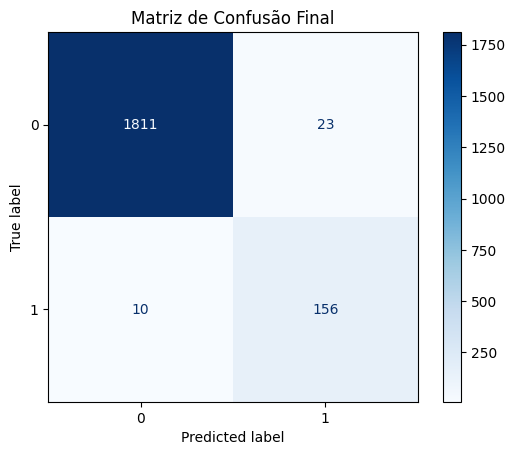

<Figure size 800x600 with 0 Axes>

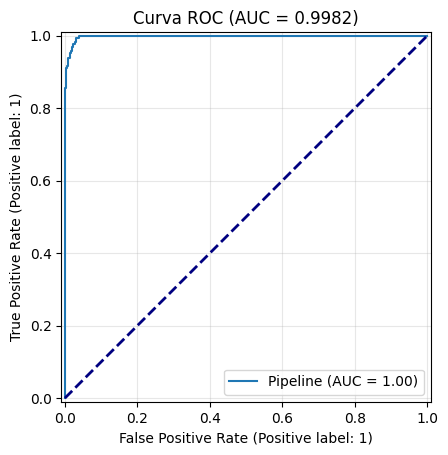

In [16]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay, roc_auc_score

y_pred = pipeline.predict(X_test)

print("=== Relatório de Classificação ===")
print(classification_report(y_test, y_pred))

# Gerando a matriz visual
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(pipeline, X_test, y_test, cmap='Blues', values_format='d')
plt.title('Matriz de Confusão Final')
plt.show()

# Calculando a pontuação AUC
# Precisamos das probabilidades para a curva ROC
y_score = pipeline.predict_proba(X_test)[:, 1]
auc_value = roc_auc_score(y_test, y_score)

# Gerando o gráfico
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(pipeline, X_test, y_test)

# Adicionando uma linha de referência (modelo aleatório)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.title(f'Curva ROC (AUC = {auc_value:.4f})')
plt.grid(True, alpha=0.3)
plt.show()